# Regresión Lineal desde Cero con NumPy

**Proyecto 0.3 | Regresión Lineal desde Cero**  
Portafolio: De Matemático a Data Scientist

---

## 1. Fundamento Matemático

La regresión lineal es, en esencia, un problema de optimización, encontrar el vector de parámetros $\beta$ que minimiza la distancia entre las predicciones $X\beta$ y los valores observados $y$. Este problema admite dos caminos de solución: una **solución analítica cerrada** (las ecuaciones normales) y una **solución iterativa** (gradient descent).

En esta sección se derivan ambas desde la función de costo, paso a paso. La formulación es matricial desde el inicio — no se parte del caso univariado — porque el dataset tiene dos features (longitude, latitude) y un intercepto, es decir, $\beta \in \mathbb{R}^3$.

### 1.1 Formulación del problema

El objetivo es encontrar una función lineal que prediga la profundidad (depth, en km) de un sismo a partir de su longitud geográfica y su latitud. El modelo tiene la forma

$$\hat{y}_i = \beta_0 + \beta_1 x_{i,1} + \beta_2 x_{i,2}$$

donde $x_{i,1}$ es la longitud (longitude) y $x_{i,2}$ la latitud (latitude) de la observación $i$-ésima. En forma matricial, esto se escribe como

$$\hat{\mathbf{y}} = X\boldsymbol{\beta}$$

con la **matriz de diseño** $X \in \mathbb{R}^{m \times (n+1)}$ que incorpora una columna de unos para el intercepto:

$$X = \begin{pmatrix} 1 & x_{1,1} & x_{1,2} \\ 1 & x_{2,1} & x_{2,2} \\ \vdots & \vdots & \vdots \\ 1 & x_{m,1} & x_{m,2} \end{pmatrix}, \qquad \boldsymbol{\beta} = \begin{pmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \end{pmatrix}$$

En este proyecto, $m = 1187$ observaciones y $n = 2$ features, de modo que $X \in \mathbb{R}^{1187 \times 3}$ y $\boldsymbol{\beta} \in \mathbb{R}^{3}$.

El problema consiste en encontrar el vector $\boldsymbol{\beta}^*$ que mejor ajuste las predicciones $X\boldsymbol{\beta}$ a los valores observados $\mathbf{y} \in \mathbb{R}^{1187}$. Para definir qué significa "mejor ajuste", se necesita una función de costo.

### 1.2 Función de costo

Para cuantificar qué tan lejos están las predicciones del modelo de los valores observados, se define la función de costo como el **error cuadrático medio** (MSE) escalado por $\frac{1}{2}$

$$J(\boldsymbol{\beta}) = \frac{1}{2m}\|X\boldsymbol{\beta} - \mathbf{y}\|^2 = \frac{1}{2m}\sum_{i=1}^{m}(\hat{y}_i - y_i)^2$$

El factor $\frac{1}{m}$ normaliza por el número de observaciones, de modo que el valor de $J$ no depende del tamaño del dataset. El factor $\frac{1}{2}$ es una conveniencia algebraica: al derivar, el exponente 2 cancela con el $\frac{1}{2}$ y se obtiene una expresión más limpia para el gradiente.

#### Expansión en forma matricial

Escribiendo la norma como producto interno

$$J(\boldsymbol{\beta}) = \frac{1}{2m}(X\boldsymbol{\beta} - \mathbf{y})^\top(X\boldsymbol{\beta} - \mathbf{y})$$

Se distribuye el producto

$$= \frac{1}{2m}\left[\boldsymbol{\beta}^\top X^\top X \boldsymbol{\beta} - \boldsymbol{\beta}^\top X^\top \mathbf{y} - \mathbf{y}^\top X\boldsymbol{\beta} + \mathbf{y}^\top \mathbf{y}\right]$$

Los términos $\boldsymbol{\beta}^\top X^\top \mathbf{y}$ y $\mathbf{y}^\top X\boldsymbol{\beta}$ son escalares ($1 \times 1$), y un escalar es igual a su transpuesto. Así, $\boldsymbol{\beta}^\top X^\top \mathbf{y} = (\mathbf{y}^\top X\boldsymbol{\beta})^\top = \mathbf{y}^\top X\boldsymbol{\beta}$. Combinándolos

$$J(\boldsymbol{\beta}) = \frac{1}{2m}\left[\boldsymbol{\beta}^\top X^\top X \boldsymbol{\beta} - 2\mathbf{y}^\top X\boldsymbol{\beta} + \mathbf{y}^\top \mathbf{y}\right]$$

Esta es la estructura canónica de una **forma cuadrática** en $\boldsymbol{\beta}$:

- **Término cuadrático:** $\boldsymbol{\beta}^\top \left(\frac{1}{2m}X^\top X\right) \boldsymbol{\beta}$
- **Término lineal:** $-\frac{1}{m}\mathbf{y}^\top X\boldsymbol{\beta}$
- **Término constante:** $\frac{1}{2m}\mathbf{y}^\top \mathbf{y}$, no depende de $\boldsymbol{\beta}$, irrelevante para la optimización

#### Convexidad y existencia de mínimo único

La matriz asociada a la parte cuadrática es $\frac{1}{m}X^\top X$ (el factor $\frac{1}{2}$ se absorbe en la convención de forma cuadrática $\frac{1}{2}\boldsymbol{\beta}^\top A\boldsymbol{\beta}$, con $A = \frac{1}{m}X^\top X$). Esta matriz es **semidefinida positiva** por construcción, para cualquier $\mathbf{v} \in \mathbb{R}^{n+1}$,

$$\mathbf{v}^\top X^\top X\,\mathbf{v} = (X\mathbf{v})^\top(X\mathbf{v}) = \|X\mathbf{v}\|^2 \geq 0$$

Por propiedad de norma, la igualdad $\|X\mathbf{v}\|^2 = 0$ ocurre si y solo si $X\mathbf{v} = \mathbf{0}$, es decir, si $\mathbf{v} \in \ker(X)$. Si las columnas de $X$ son linealmente independientes, entonces $\ker(X) = \{\mathbf{0}\}$, lo que implica $\mathbf{v}^\top X^\top X\,\mathbf{v} > 0$ para todo $\mathbf{v} \neq \mathbf{0}$, con lo cual, la matriz es **definida positiva**.

Queda por demostrar que este mínimo **existe** y que es **único**. Dos afirmaciones distintas, pero complementarias.

#### Existencia del mínimo: Teorema de Weierstrass y coercividad

El Teorema de Weierstrass clásico garantiza que una función continua en un conjunto **compacto** (cerrado y acotado) alcanza su mínimo. Sin embargo, el dominio de $J$ es $\mathbb{R}^{n+1}$, que no es acotado, así que la versión clásica no aplica directamente.

La herramienta correcta es la extensión del teorema para **funciones coercivas**: si $f: \mathbb{R}^n \to \mathbb{R}$ es continua y coerciva (es decir, $f(\mathbf{x}) \to +\infty$ cuando $\|\mathbf{x}\| \to \infty$), entonces $f$ alcanza su mínimo global.

$J$ es continua porque es un polinomio en las componentes de $\boldsymbol{\beta}$. Para demostrar que es coerciva, se analiza el término cuadrático dominante. Como $X^\top X$ es definida positiva, todos sus valores propios son estrictamente positivos. Por lo cual, vale la descomposición espectral, así $X^\top X = Q\Lambda Q^\top$ con $Q$ ortogonal y $\Lambda = \text{diag}(\lambda_1, \ldots, \lambda_{n+1})$, entonces 

$$\boldsymbol{\beta}^\top X^\top X\,\boldsymbol{\beta} = \sum_j \lambda_j (Q^\top\boldsymbol{\beta})_j^2 \geq \lambda_{\min}\sum_j (Q^\top\boldsymbol{\beta})_j^2 = \lambda_{\min}\|\boldsymbol{\beta}\|^2,$$ donde la última igualdad usa que $Q$ es ortogonal y preserva el producto interno (y por tanto la norma $\|Q^\top\boldsymbol{\beta}\| = \|\boldsymbol{\beta}\|$). Formalmente, sea $\lambda_{\min} > 0$ el menor de dichos valores propios. Entonces, para todo $\boldsymbol{\beta} \in \mathbb{R}^{n+1}$

$$\boldsymbol{\beta}^\top X^\top X\,\boldsymbol{\beta} \geq \lambda_{\min}\|\boldsymbol{\beta}\|^2.$$

Volviendo a $J$ en su forma expandida:

$$J(\boldsymbol{\beta}) = \frac{1}{2m}\boldsymbol{\beta}^\top X^\top X\,\boldsymbol{\beta} - \frac{1}{m}\mathbf{y}^\top X\boldsymbol{\beta} + \frac{1}{2m}\mathbf{y}^\top\mathbf{y}$$

El primer término crece como $\|\boldsymbol{\beta}\|^2$ (cota inferior: $\frac{\lambda_{\min}}{2m}\|\boldsymbol{\beta}\|^2$). El segundo crece a lo sumo como $\|\boldsymbol{\beta}\|$ (por la desigualdad de Cauchy-Schwarz: $|\mathbf{y}^\top X\boldsymbol{\beta}| \leq \|X^\top\mathbf{y}\|\,\|\boldsymbol{\beta}\|$). El tercero es constante. Por lo tanto, cuando $\|\boldsymbol{\beta}\| \to \infty$, el término cuadrático domina y $J(\boldsymbol{\beta}) \to +\infty$. Luego $J$ es coerciva.

Por el Teorema de Weierstrass (versión coerciva), $J$ **alcanza su mínimo global**. $\blacksquare$

#### Unicidad del mínimo: convexidad estricta

La existencia por sí sola no descarta la posibilidad de múltiples mínimos globales, pues una función continua y coerciva podría tener mas de uno. Para garantizar **unicidad** se necesita **convexidad estricta**.

La herramienta es la **Hessiana** de $J$. Vamos a calcular la segunda derivada (matricial) de $J$ respecto a $\boldsymbol{\beta}$.  
El gradiente es $\nabla_{\boldsymbol{\beta}}J = \frac{1}{m}X^\top(X\boldsymbol{\beta} - \mathbf{y}) = \frac{1}{m}X^\top X\boldsymbol{\beta} - \frac{1}{m}X^\top\mathbf{y}$, y al derivar nuevamente respecto a $\boldsymbol{\beta}$, el término lineal $\frac{1}{m}X^\top X\boldsymbol{\beta}$ produce $\frac{1}{m}X^\top X$ y el término constante desaparece. Resultando así

$$H_J = \nabla^2_{\boldsymbol{\beta}} J = \frac{1}{m}X^\top X$$

En optimización, la clasificación de convexidad depende de la Hessiana

| Condición sobre $H_J$ | Tipo de convexidad | Consecuencia para mínimos |
|---|---|---|
| Semidefinida positiva ($\geq 0$) | Convexa | Si existe mínimo, puede no ser único |
| **Definida positiva** ($> 0$) | **Estrictamente convexa** | Si existe mínimo, **es único** |

Ya se demostró que $X^\top X$ es definida positiva (bajo independencia lineal de columnas de $X$), por lo tanto $H_J = \frac{1}{m}X^\top X$ también lo es (un escalar positivo por una matriz definida positiva es definida positiva). Esto implica que $J$ es **estrictamente convexa**.

Finalmente, el teorema que cierra el argumento es que, **si una función estrictamente convexa en un conjunto convexo tiene un mínimo, entonces ese mínimo es único**. 

Demostración.

Procedemos por contradicción, si existieran dos mínimos globales distintos $\boldsymbol{\beta}_1^* \neq \boldsymbol{\beta}_2^*$ con $J(\boldsymbol{\beta}_1^*) = J(\boldsymbol{\beta}_2^*) = J^*$, la convexidad estricta con $t = \frac{1}{2}$ daría:

$$J\!\left(\frac{\boldsymbol{\beta}_1^* + \boldsymbol{\beta}_2^*}{2}\right) < \frac{1}{2}J(\boldsymbol{\beta}_1^*) + \frac{1}{2}J(\boldsymbol{\beta}_2^*) = \frac{1}{2}J(\boldsymbol{\beta}_1^*) + \frac{1}{2}J(\boldsymbol{\beta}_1^*) = J^*$$

lo cual contradice que $J^*$ sea el valor mínimo global. $\blacksquare$

**En conclusión,** la existencia del mínimo se garantiza por continuidad + coercividad (Weierstrass), y la unicidad por convexidad estricta ($X^\top X$ definida positiva). Ambas condiciones dependen de que las columnas de $X$ sean linealmente independientes, hipótesis que se verificará numéricamente en la Sección 2.

### 1.3 Derivación del gradiente

Para minimizar $J(\boldsymbol{\beta})$, se necesita su gradiente respecto a $\boldsymbol{\beta}$. Se parte de la forma expandida obtenida en la sección anterior

$$J(\boldsymbol{\beta}) = \frac{1}{2m}\left[\boldsymbol{\beta}^\top X^\top X \boldsymbol{\beta} - 2\mathbf{y}^\top X\boldsymbol{\beta} + \mathbf{y}^\top \mathbf{y}\right]$$

Se deriva término por término. Se utilizan dos identidades estándar del cálculo matricial, que se demuestran a continuación.

#### 1.3.1 $\nabla_{\boldsymbol{\beta}}\left(\mathbf{c}^\top \boldsymbol{\beta}\right) = \mathbf{c}$

Demostración.

Sean $\mathbf{c}, \boldsymbol{\beta} \in \mathbb{R}^{n}$, el producto se escribe como $\mathbf{c}^\top \boldsymbol{\beta} = \sum_{j=1}^{n} c_j \beta_j$. Se deriva respecto a $\beta_k$

$$\frac{\partial}{\partial \beta_k}\sum_{j=1}^{n} c_j \beta_j = c_k$$

porque todos los términos con $j \neq k$ son constantes respecto a $\beta_k$. Esto vale para cada $k = 1, \ldots, n$, así que

$$\nabla_{\boldsymbol{\beta}}\left(\mathbf{c}^\top \boldsymbol{\beta}\right) = \begin{pmatrix} c_1 \\ \vdots \\ c_n \end{pmatrix} = \mathbf{c}$$

Es el análogo multivariable de $\frac{d}{dx}(cx) = c$. $\blacksquare$

#### 1.3.2 $\nabla_{\boldsymbol{\beta}}\left(\boldsymbol{\beta}^\top A \boldsymbol{\beta}\right) = (A + A^\top)\boldsymbol{\beta}$

Demostración.

Si $A \in \mathbb{R}^{n \times n}$ y $\boldsymbol{\beta} \in \mathbb{R}^{n}$, el producto se escribe como

$$\boldsymbol{\beta}^\top A \boldsymbol{\beta} = \sum_{i=1}^{n}\sum_{j=1}^{n} \beta_i \, a_{ij} \, \beta_j$$

Se deriva respecto a $\beta_k$. Los términos de la doble suma que contienen $\beta_k$ aparecen en dos roles:

- Cuando $i = k$ (y $j$ varía): aporta $\sum_{j=1}^{n} a_{kj}\,\beta_j$
- Cuando $j = k$ (e $i$ varía): aporta $\sum_{i=1}^{n} a_{ik}\,\beta_i$

El caso $i = k,\, j = k$ (término $a_{kk}\beta_k^2$, que se deriva como $2a_{kk}\beta_k$) ya está contado correctamente en ambas sumas ($a_{kk}\beta_k$ de la primera + $a_{kk}\beta_k$ de la segunda). Entonces

$$\frac{\partial}{\partial \beta_k}\left(\boldsymbol{\beta}^\top A \boldsymbol{\beta}\right) = \sum_{j=1}^{n} a_{kj}\,\beta_j + \sum_{i=1}^{n} a_{ik}\,\beta_i$$

La primera suma es $(A\boldsymbol{\beta})_k$ (fila $k$ de $A$ por $\boldsymbol{\beta}$). La segunda es $(A^\top\boldsymbol{\beta})_k$ (fila $k$ de $A^\top$ por $\boldsymbol{\beta}$). Juntando para todo $k$:

$$\nabla_{\boldsymbol{\beta}}\left(\boldsymbol{\beta}^\top A \boldsymbol{\beta}\right) = A\boldsymbol{\beta} + A^\top\boldsymbol{\beta} = (A + A^\top)\boldsymbol{\beta}$$

Cuando $A$ es simétrica ($A = A^\top$), esto se simplifica a $(A + A)\boldsymbol{\beta} = 2A\boldsymbol{\beta}$. $\blacksquare$

#### Aplicación a $J(\boldsymbol{\beta})$

**Término cuadrático:** $\nabla_{\boldsymbol{\beta}}\left(\boldsymbol{\beta}^\top X^\top X \boldsymbol{\beta}\right)$. La matriz $X^\top X$ es simétrica (pues $(X^\top X)^\top = X^\top X$), así que por la identidad (1)

$$\nabla_{\boldsymbol{\beta}}\left(\boldsymbol{\beta}^\top X^\top X \boldsymbol{\beta}\right) = 2X^\top X \boldsymbol{\beta}$$

**Término lineal:** $\nabla_{\boldsymbol{\beta}}\left(-2\mathbf{y}^\top X\boldsymbol{\beta}\right)$. Se reescribe $-2(\mathbf{y}^\top X)\boldsymbol{\beta}$ como $-2(X^\top \mathbf{y})^\top \boldsymbol{\beta}$. Luego, por la identidad (2) con $\mathbf{c} = -2X^\top \mathbf{y}$

$$\nabla_{\boldsymbol{\beta}}\left(-2\mathbf{y}^\top X\boldsymbol{\beta}\right) = -2X^\top \mathbf{y}$$

**Término constante:** $\nabla_{\boldsymbol{\beta}}\left(\mathbf{y}^\top \mathbf{y}\right) = \mathbf{0}$, no depende de $\boldsymbol{\beta}$.

Combinando los tres términos con el factor $\frac{1}{2m}$

$$\nabla_{\boldsymbol{\beta}} J = \frac{1}{2m}\left[2X^\top X \boldsymbol{\beta} - 2X^\top \mathbf{y}\right] = \frac{1}{m}X^\top\left(X\boldsymbol{\beta} - \mathbf{y}\right)$$

Este resultado tiene una interpretación directa: el gradiente es proporcional a $X^\top \mathbf{r}$, donde $\mathbf{r} = X\boldsymbol{\beta} - \mathbf{y}$ es el vector de residuos. Cada componente $(\nabla_{\boldsymbol{\beta}} J)_j = \frac{1}{m}\sum_{i=1}^{m} r_i \, x_{ij}$ mide cuánto contribuye la feature $j$-ésima al error total, ponderada por los propios residuos.

### 1.4 Solución analítica: ecuaciones normales

El mínimo de $J$ se encuentra donde su gradiente se anula. Igualando a cero la expresión derivada en la sección 1.3

$$\nabla_{\boldsymbol{\beta}} J = \frac{1}{m}X^\top(X\boldsymbol{\beta} - \mathbf{y}) = \mathbf{0}$$

El factor $\frac{1}{m}$ es un escalar positivo, así que se puede eliminar sin alterar la igualdad

$$X^\top(X\boldsymbol{\beta} - \mathbf{y}) = \mathbf{0}$$

Distribuyendo el producto

$$X^\top X\,\boldsymbol{\beta} = X^\top \mathbf{y}$$

Este es un sistema de ecuaciones lineales conocido como las **ecuaciones normales**. La incógnita es $\boldsymbol{\beta} \in \mathbb{R}^{n+1}$ y la matriz del sistema es $X^\top X \in \mathbb{R}^{(n+1) \times (n+1)}$.

Ya se demostró (en la sección 1.2) que si las columnas de $X$ son linealmente independientes, $X^\top X$ es definida positiva. Luego, una matriz definida positiva tiene todos sus valores propios estrictamente positivos, lo que implica que su determinante es no nulo (el determinante es el producto de los valores propios). Por lo tanto, $X^\top X$ es invertible y el sistema tiene solución única

$$\hat{\boldsymbol{\beta}} = (X^\top X)^{-1}X^\top \mathbf{y}$$

#### Nota para la implementación: `np.linalg.solve` vs. `np.linalg.inv`

La fórmula cerrada $\hat{\boldsymbol{\beta}} = (X^\top X)^{-1}X^\top \mathbf{y}$ sugiere calcular la inversa de $X^\top X$ explícitamente. En la práctica, esto es innecesario y numéricamente desaconsejable. Calcular la inversa de una matriz tiene complejidad $O(n^3)$ y amplifica los errores de redondeo. En cambio, resolver el sistema lineal $X^\top X\,\boldsymbol{\beta} = X^\top \mathbf{y}$ directamente (por ejemplo, mediante descomposición de Cholesky ($ A = LL^\top o $ $ A = U^\top U$, ambas equivalentes, donde L es matriz triangular inferior y U matriz triangular superior), que explota la simetría y definitud positiva de $X^\top X$) es más estable y eficiente.

En NumPy, esto se traduce en usar `np.linalg.solve(X.T @ X, X.T @ y)` en lugar de `np.linalg.inv(X.T @ X) @ X.T @ y`. La función `solve` elige internamente el método de factorización apropiado.

### 1.5 Gradient Descent

La solución analítica resuelve el problema de forma exacta en un solo paso. Sin embargo, requiere resolver un sistema lineal de tamaño $(n+1) \times (n+1)$, lo que para datasets con muchas features puede ser costoso. **Gradient descent** ofrece una alternativa iterativa: en lugar de resolver el sistema, se parte de un punto inicial arbitrario y se avanza repetidamente en la dirección opuesta al gradiente. Como se ve a continuación.

#### Derivación de la ecuación de recurrencia

Se parte de un punto $\boldsymbol{\beta}_t$ y se busca una dirección $\mathbf{d}$ tal que moverse a $\boldsymbol{\beta}_t + \mathbf{d}$ disminuya el valor de $J$. Aproximamos usando su expansión en serie de Taylor de primer orden alrededor de $\boldsymbol{\beta}_t$, que resulta

$$J(\boldsymbol{\beta}_t + \mathbf{d}) \approx J(\boldsymbol{\beta}_t) + \nabla_{\boldsymbol{\beta}} J(\boldsymbol{\beta}_t)^\top \mathbf{d}$$

Para que $J$ disminuya, se necesita que el segundo término sea negativo, $\nabla_{\boldsymbol{\beta}} J(\boldsymbol{\beta}_t)^\top \mathbf{d} < 0$. Debemos de preguntarnos, entre todas las direcciones unitarias (es decir, $\|\mathbf{d}\| = 1$), ¿cuál hace que este producto sea lo más negativo posible? Notemos que el producto $\nabla_{\boldsymbol{\beta}} J(\boldsymbol{\beta}_t)^\top \mathbf{d}$ es un escalar, así por la desigualdad de Cauchy-Schwarz

$$|\nabla J^\top \mathbf{d}| \leq \|\nabla J\|\,\|\mathbf{d}\|$$

Como $\|\mathbf{d}\| = 1$, esto se reduce a $|\nabla J^\top \mathbf{d}| \leq \|\nabla J\|$. Luego, por definición de valor absoluto, $|a| \leq b$ equivale a $-b \leq a \leq b$, así que

$$-\|\nabla J\| \leq \nabla J^\top \mathbf{d} \leq \|\nabla J\|$$

La cota derecha corresponde al máximo crecimiento de $J$ (cuando $\mathbf{d}$ apunta en la misma dirección que $\nabla J$). La cota izquierda corresponde al **máximo descenso** — la que interesa, pues se busca que $\nabla J^\top \mathbf{d}$ sea lo más negativo posible.

La igualdad en Cauchy-Schwarz se alcanza cuando los vectores son linealmente dependientes. Para alcanzar la cota inferior, se necesita $\mathbf{d}^* = -\nabla_{\boldsymbol{\beta}} J / \|\nabla_{\boldsymbol{\beta}} J\|$, osea, la dirección opuesta al gradiente, normalizada. Esta es la **dirección de máximo descenso**. De aquí, incorporando un tamaño de paso $\alpha > 0$ (que absorbe la normalización por la norma), se llega a la ecuación de recurrencia

$$\boldsymbol{\beta}_{t+1} = \boldsymbol{\beta}_t - \alpha\,\nabla_{\boldsymbol{\beta}}J(\boldsymbol{\beta}_t)$$

Sustituyendo la expresión del gradiente derivada en la sección 1.3

$$\boldsymbol{\beta}_{t+1} = \boldsymbol{\beta}_t - \frac{\alpha}{m}\,X^\top(X\boldsymbol{\beta}_t - \mathbf{y})$$

donde $\alpha > 0$ es la **tasa de aprendizaje** (learning rate) y $t = 0, 1, 2, \ldots$ indexa las iteraciones (épocas).

#### Interpretación geométrica

En cada iteración, el gradiente $\nabla_{\boldsymbol{\beta}}J(\boldsymbol{\beta}_t)$ apunta en la dirección de **máximo crecimiento** de $J$ desde el punto actual $\boldsymbol{\beta}_t$. Al restar $\alpha\,\nabla J$, el algoritmo se mueve en la dirección de **máximo descenso**, es decir, hacia donde $J$ decrece más rápidamente. Como $J$ es estrictamente convexa (demostrado en la sección 1.2), toda dirección de descenso conduce eventualmente al único mínimo global.

#### Rol de la tasa de aprendizaje $\alpha$

La tasa de aprendizaje controla el tamaño del paso en cada iteración:

- **Si $\alpha$ es demasiado pequeño:** los pasos son diminutos, la convergencia es correcta pero extremadamente lenta — se necesitan miles o millones de iteraciones.
- **Si $\alpha$ es demasiado grande:** los pasos sobrepasan el mínimo, el algoritmo oscila y puede diverger ($J$ crece en lugar de decrecer).
- **Si $\alpha$ es el adecuado:** la secuencia $J(\boldsymbol{\beta}_0), J(\boldsymbol{\beta}_1), J(\boldsymbol{\beta}_2), \ldots$ decrece monótonamente y converge al mínimo global.

La elección de $\alpha$ se explorará experimentalmente en la Sección 4.

#### Criterio de convergencia

El algoritmo se detiene cuando se cumple al menos una de estas condiciones:

1. Se alcanza un número máximo de iteraciones (épocas).
2. El cambio en la función de costo entre iteraciones consecutivas cae por debajo de una tolerancia: $|J(\boldsymbol{\beta}_{t+1}) - J(\boldsymbol{\beta}_t)| < \varepsilon$.

En la implementación se usará la condición (1) como criterio principal, con la curva de loss como verificación visual de que la convergencia ocurrió.

### 1.6 Solución analítica vs. Gradient Descent

Ambos métodos llegan al mismo $\hat{\boldsymbol{\beta}}$ (el mínimo único de $J$, cuya existencia y unicidad se demostraron en la sección 1.2). La diferencia entonces es más operativa: cómo lo alcanzan y a qué costo.

| Aspecto | Solución analítica | Gradient Descent |
|---|---|---|
| **Tipo de solución** | Exacta, en un solo paso | Aproximada, iterativa |
| **Operación central** | Resolver $X^\top X\,\boldsymbol{\beta} = X^\top \mathbf{y}$ | Aplicar la ecuación de recurrencia $T$ veces |
| **Complejidad** | $O(n^3)$ para resolver el sistema ($n$ = número de features) | $O(m \cdot n)$ por iteración ($m$ = observaciones), multiplicado por $T$ iteraciones |
| **Escala bien cuando** | $n$ es pequeño (cientos o pocos miles de features) | $m$ y/o $n$ son grandes (millones de observaciones o features) |
| **Hiperparámetros** | Ninguno | $\alpha$ (tasa de aprendizaje), $T$ (épocas), $\varepsilon$ (tolerancia) |
| **Puede fallar si** | $X^\top X$ es singular o mal condicionada (columnas de $X$ linealmente dependientes o casi dependientes) | $\alpha$ es demasiado grande (divergencia) o demasiado pequeño (convergencia impráctica) |
| **Requiere normalización** | No (la solución es invariante a la escala de las features) | Sí — features en escalas diferentes distorsionan las curvas de nivel de $J$, haciendo que el descenso oscile |

En este proyecto, con $n = 2$ features y $m = 1187$ observaciones, la solución analítica es computacionalmente trivial (un sistema $3 \times 3$). Se implementan ambos métodos con fin pedagógico, la solución analítica como referencia exacta y gradient descent como el algoritmo que escala a próximos proyectos, donde la solución analítica deja de ser viable.

## 2. Implementación con NumPy

En esta sección se implementa una clase `RegresionLineal` que resuelve el problema de mínimos cuadrados por ambos métodos derivados en la Sección 1, la solución analítica (ecuaciones normales) y gradient descent. Al final se comparan los coeficientes obtenidos por ambos caminos para verificar que convergen al mismo mínimo.

Se trabaja sobre el dataset procesado `sismos_clean.csv` (1187 filas × 3 columnas: longitude, latitude, depth) generado en el Notebook 01.

**Nota sobre la ausencia de partición de datos:** este notebook no divide los datos en conjuntos de entrenamiento, validación y prueba. En un flujo completo de ML, la partición debe hacerse en tres conjuntos: **entrenamiento** (para ajustar los parámetros del modelo), **validación** (para tomar decisiones intermedias como selección de modelo o ajuste de hiperparámetros — se puede evaluar repetidamente) y **prueba** (para evaluar el rendimiento final **una sola vez**, simulando datos que el modelo nunca ha visto ni directa ni indirectamente). Si se usa el mismo conjunto para elegir hiperparámetros y para reportar rendimiento, la evaluación queda contaminada, pues el modelo fue indirectamente optimizado para esos datos. Aquí no se realiza ninguna partición porque el objetivo no es evaluar generalización, sino verificar que la implementación propia reproduce los mismos coeficientes que Scikit-learn sobre los mismos datos. La evaluación con partición completa corresponde a proyectos posteriores del portafolio.

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/sismos_clean.csv")

print(f"Dimensiones: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")
df.head()

Dimensiones: 1187 filas × 3 columnas
Columnas: ['longitude', 'latitude', 'depth']


,longitude,latitude,depth
0,-77.9623,-0.7716,10.000
1,-77.7537,-1.5529,181.434
2,-78.0415,-1.7675,155.618
3,-79.0621,-1.7801,10.000
4,-77.8568,-1.3210,177.305


### 2.1 Preparación de la matriz de diseño

La formulación matricial $\hat{\mathbf{y}} = X\boldsymbol{\beta}$ requiere que la matriz de diseño $X$ incluya una columna de unos a la izquierda para representar el intercepto $\beta_0$ (sección 1.1). A partir del DataFrame con columnas `longitude` y `latitude`, se construye:

$$X = \begin{pmatrix} 1 & \text{lon}_1 & \text{lat}_1 \\ 1 & \text{lon}_2 & \text{lat}_2 \\ \vdots & \vdots & \vdots \\ 1 & \text{lon}_{1187} & \text{lat}_{1187} \end{pmatrix} \in \mathbb{R}^{1187 \times 3}, \qquad \mathbf{y} = \begin{pmatrix} \text{depth}_1 \\ \text{depth}_2 \\ \vdots \\ \text{depth}_{1187} \end{pmatrix} \in \mathbb{R}^{1187}$$

In [3]:
features = df[["longitude", "latitude"]].values
ones_column = np.ones((features.shape[0], 1))
X = np.hstack([ones_column, features])

y = df["depth"].values

print(f"X: {X.shape}")
print(f"y: {y.shape}")
print(f"\nPrimeras 3 filas de X:")
print(X[:3])

X: (1187, 3)
y: (1187,)

Primeras 3 filas de X:
[[  1.     -77.9623  -0.7716]
 [  1.     -77.7537  -1.5529]
 [  1.     -78.0415  -1.7675]]


### 2.2 Normalización de features

Las dos features tienen escalas muy diferentes: longitude varía aproximadamente entre $-81$ y $-75$ mientras que latitude varía entre $-5$ y $2$. Para gradient descent, esto es un problema, ya que las curvas de nivel de $J$ se deforman en elipses alargadas, lo que provoca que el algoritmo oscile en la dirección de la feature con mayor escala y avance lentamente en la otra.

La normalización lleva ambas features a una escala comparable. Se consideraron tres opciones:

| Opción | Transformación | Rango resultante | Observación |
|---|---|---|---|
| Sin normalizar | Ninguna | Original | Válido para solución analítica, problemático para GD |
| Min-Max | $(x - x_{\min}) / (x_{\max} - x_{\min})$ | $[0, 1]$ | Sensible a outliers extremos |
| **Z-score** | $(x - \mu) / \sigma$ | $\approx [-3, 3]$ | Robusta, centrada en cero, estándar para ML |

Se elige **z-score** (estandarización) porque centra los datos en cero y escala por la desviación estándar, lo que produce curvas de nivel más circulares para $J$ y facilita la convergencia de gradient descent. Se normaliza solo las features (columnas 1 y 2 de $X$), no la columna de unos ni el vector objetivo $\mathbf{y}$.

Para que la comparación entre los coeficientes del método analítico, gradient descent y Scikit-learn sea directa (en el mismo espacio), se aplica la misma normalización a los datos que reciben los tres métodos.

In [4]:
mu = X[:, 1:].mean(axis=0)
sigma = X[:, 1:].std(axis=0)

X_norm = X.copy()
X_norm[:, 1:] = (X[:, 1:] - mu) / sigma

print(f"Medias originales:      {mu}")
print(f"Desviaciones originales: {sigma}")
print(f"\nMedias tras normalizar:      {X_norm[:, 1:].mean(axis=0)}")
print(f"Desviaciones tras normalizar: {X_norm[:, 1:].std(axis=0)}")
print(f"\nPrimeras 3 filas de X_norm:")
print(X_norm[:3])

Medias originales:      [-79.04323361  -1.83432308]
Desviaciones originales: [1.5558539  1.89324668]

Medias tras normalizar:      [-1.23218855e-14 -3.42794219e-17]
Desviaciones tras normalizar: [1. 1.]

Primeras 3 filas de X_norm:
[[1.         0.69475265 0.56132309]
 [1.         0.82882693 0.14864576]
 [1.         0.64384812 0.0352955 ]]


### 2.3 Clase RegresionLineal

Se implementa una clase con la siguiente interfaz:

- **`fit(X, y, metodo)`:** entrena el modelo por el método especificado (`'analitico'` o `'gradiente'`). Para gradient descent, acepta adicionalmente los hiperparámetros `alpha` (tasa de aprendizaje), `epocas` (número de iteraciones) y `tolerancia` (criterio de parada opcional).
- **`predict(X)`:** calcula las predicciones $\hat{\mathbf{y}} = X\boldsymbol{\beta}$.

Atributos accesibles tras el entrenamiento:

- `coeficientes_`: vector $\boldsymbol{\beta}$ completo (intercepto + features).
- `intercepto_`: valor de $\beta_0$ (extraído de `coeficientes_` por conveniencia).
- `historial_loss_`: lista con el valor de $J$ en cada época (solo para gradient descent, útil para graficar la curva de convergencia).

In [5]:
class RegresionLineal:
    """Regresión lineal implementada desde cero con NumPy.

    Soporta dos métodos de ajuste:
    - 'analitico': ecuaciones normales via np.linalg.solve
    - 'gradiente': gradient descent con tasa de aprendizaje fija

    Atributos tras fit():
        coeficientes_ : np.ndarray, vector beta completo (intercepto + features)
        intercepto_   : float, valor de beta_0
        historial_loss_ : list, valor de J por época (solo gradient descent)
    """

    def __init__(self):
        self.coeficientes_ = None
        self.intercepto_ = None
        self.historial_loss_ = None

    def _costo(self, X, y, beta):
        """Calcula J(beta) = (1/2m) * ||X*beta - y||^2."""
        m = X.shape[0]
        residuos = X @ beta - y
        return (1 / (2 * m)) * (residuos @ residuos)

    def fit(self, X, y, metodo="analitico", alpha=0.01, epocas=1000, tolerancia=1e-8):
        """Ajusta el modelo a los datos.

        Parámetros:
            X         : np.ndarray de forma (m, n+1), matriz de diseño con columna de unos
            y         : np.ndarray de forma (m,), vector objetivo
            metodo    : str, 'analitico' o 'gradiente'
            alpha     : float, tasa de aprendizaje (solo gradient descent)
            epocas    : int, número máximo de iteraciones (solo gradient descent)
            tolerancia: float, criterio de parada por cambio en J (solo gradient descent)

        Retorna:
            self (permite encadenar: modelo.fit(X, y).predict(X))
        """
        if metodo == "analitico":
            self._fit_analitico(X, y)
        elif metodo == "gradiente":
            self._fit_gradiente(X, y, alpha, epocas, tolerancia)
        else:
            raise ValueError(f"Método '{metodo}' no reconocido. Usar 'analitico' o 'gradiente'.")

        self.intercepto_ = self.coeficientes_[0]
        return self

    def _fit_analitico(self, X, y):
        """Resuelve las ecuaciones normales: X^T X beta = X^T y."""
        self.coeficientes_ = np.linalg.solve(X.T @ X, X.T @ y)
        self.historial_loss_ = None

    def _fit_gradiente(self, X, y, alpha, epocas, tolerancia):
        """Gradient descent: beta_{t+1} = beta_t - (alpha/m) X^T (X beta_t - y)."""
        m, n = X.shape
        beta = np.zeros(n)
        self.historial_loss_ = []

        for epoca in range(epocas):
            gradiente = (1 / m) * (X.T @ (X @ beta - y))
            beta = beta - alpha * gradiente

            loss = self._costo(X, y, beta)
            self.historial_loss_.append(loss)

            if epoca > 0 and abs(self.historial_loss_[-2] - loss) < tolerancia:
                break

        self.coeficientes_ = beta

    def predict(self, X):
        """Calcula predicciones: y_hat = X @ beta.

        Parámetros:
            X : np.ndarray de forma (m, n+1), matriz de diseño con columna de unos

        Retorna:
            np.ndarray de forma (m,), predicciones
        """
        return X @ self.coeficientes_

### 2.4 Entrenamiento: solución analítica

Se instancia el modelo y se entrena con el método analítico sobre los datos normalizados. Los coeficientes resultantes corresponden a $\beta_0$ (intercepto), $\beta_1$ (longitude normalizada) y $\beta_2$ (latitude normalizada).

In [6]:
modelo_analitico = RegresionLineal()
modelo_analitico.fit(X_norm, y, metodo="analitico")

print("Coeficientes (solución analítica):")
print(f"  β₀ (intercepto): {modelo_analitico.intercepto_}")
print(f"  β₁ (longitude):  {modelo_analitico.coeficientes_[1]}")
print(f"  β₂ (latitude):   {modelo_analitico.coeficientes_[2]}")

Coeficientes (solución analítica):
  β₀ (intercepto): 62.14902021903996
  β₁ (longitude):  27.920647062413487
  β₂ (latitude):   -9.346749135856683


### 2.5 Entrenamiento: Gradient Descent

Se entrena un segundo modelo con gradient descent sobre los mismos datos normalizados. Se eligen los hiperparámetros iniciales:

- **Tasa de aprendizaje** $\alpha = 0.1$: un valor moderado para empezar; en la Sección 4 se explorará el efecto de variar $\alpha$.
- **Épocas** $= 1000$: suficientes para que el algoritmo converja en un problema de esta escala.
- **Tolerancia** $= 10^{-8}$: si el cambio en $J$ entre iteraciones consecutivas es menor que este valor, el algoritmo se detiene anticipadamente.

In [7]:
modelo_gd = RegresionLineal()
modelo_gd.fit(X_norm, y, metodo="gradiente", alpha=0.1, epocas=1000, tolerancia=1e-8)


print(f"\nCoeficientes (gradient descent):")
print(f"  β₀ (intercepto): {modelo_gd.intercepto_}")
print(f"  β₁ (longitude):  {modelo_gd.coeficientes_[1]}")
print(f"  β₂ (latitude):   {modelo_gd.coeficientes_[2]}")

Convergió en 118 épocas

Coeficientes (gradient descent):
  β₀ (intercepto): 62.14877244808184
  β₁ (longitude):  27.92052358262598
  β₂ (latitude):   -9.346814922627265


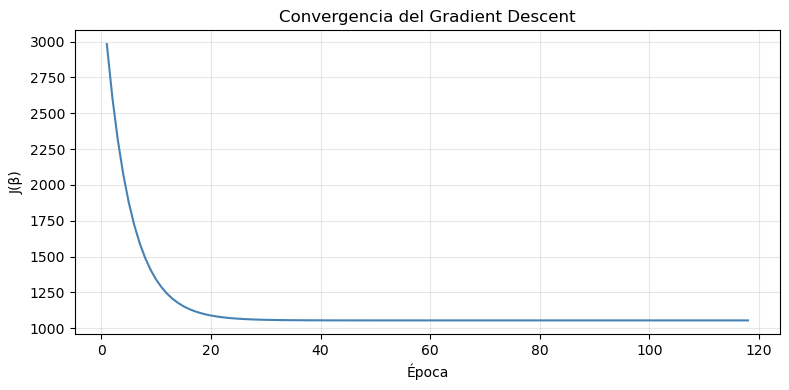

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(range(1, len(modelo_gd.historial_loss_) + 1), modelo_gd.historial_loss_, color="steelblue")
ax.set_xlabel("Época")
ax.set_ylabel("J(β)")
ax.set_title("Convergencia del Gradient Descent")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("../reports/figures/convergencia_gd.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.6 Comparación de coeficientes

Los dos métodos resuelven el mismo problema de optimización (minimizar $J$) y, por la unicidad del mínimo demostrada en la sección 1.2, deben producir coeficientes que coincidan dentro de la precisión numérica. La siguiente tabla compara los resultados y cuantifica la diferencia absoluta.

In [9]:
nombres = ["β₀ (intercepto)", "β₁ (longitude)", "β₂ (latitude)"]
coefs_analitico = modelo_analitico.coeficientes_
coefs_gd = modelo_gd.coeficientes_
diferencias = np.abs(coefs_analitico - coefs_gd)

comparacion = pd.DataFrame({
    "Coeficiente": nombres,
    "Analítico": coefs_analitico,
    "Gradient Descent": coefs_gd,
    "Diferencia absoluta": diferencias
})

print(f"La diferencia máxima: {diferencias.max():.2e}")
print()
comparacion

La diferencia máxima: 2.48e-04



,Coeficiente,Analítico,Gradient Descent,Diferencia absoluta
0,β₀ (intercepto),62.149020,62.148772,0.000248
1,β₁ (longitude),27.920647,27.920524,0.000123
2,β₂ (latitude),-9.346749,-9.346815,0.000066


### 2.7 Métricas de ajuste

Antes de verificar contra Scikit-learn, se evalúa qué tan bien el modelo lineal se ajusta a los datos. Se calculan tres métricas complementarias usando las predicciones del modelo analítico (la solución exacta):

- **$R^2$ (coeficiente de determinación):** proporción de la varianza de $y$ explicada por el modelo. Definido como $R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$. Un valor de 1 indica ajuste perfecto; un valor de 0 indica que el modelo no explica más que la media.
- **RMSE (raíz del error cuadrático medio):** $\sqrt{\frac{1}{m}\sum_i(y_i - \hat{y}_i)^2}$. Está en las mismas unidades que $y$ (km), lo que facilita la interpretación directa.
- **MAE (error absoluto medio):** $\frac{1}{m}\sum_i |y_i - \hat{y}_i|$. Menos sensible a errores grandes que el RMSE. También en km.

Con lo cual, notamos que $R^2$ por sí solo no es suficiente como indicador de calidad. Pues un $R^2$ moderado podría esconder errores grandes en subgrupos de los datos (por ejemplo, los sismos corticales vs. los de subducción). Las tres métricas juntas dan una imagen más completa. Así,

In [10]:
y_pred = modelo_analitico.predict(X_norm)
residuos = y - y_pred

ss_res = np.sum(residuos ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)

r2 = 1 - ss_res / ss_tot
rmse = np.sqrt(np.mean(residuos ** 2))
mae = np.mean(np.abs(residuos))

metricas = pd.DataFrame({
    "Métrica": ["R²", "RMSE (km)", "MAE (km)"],
    "Valor": [f"{r2:.4f}", f"{rmse:.2f}", f"{mae:.2f}"]
})

metricas

,Métrica,Valor
0,R²,0.3000
1,RMSE (km),45.94
2,MAE (km),34.61


## 3. Verificación contra Scikit-learn

Esta implementación propia debe producir resultados indistinguibles de la implementación estándar de la industria. Es así que se entrena un `LinearRegression` de Scikit-learn sobre los mismos datos normalizados y se comparan los coeficientes. El criterio de éxito es que la diferencia máxima sea menor que $10^{-6}$.

Se compara solo contra la solución analítica, que es exacta. La diferencia residual de gradient descent ($\sim 10^{-4}$, sección 2.6) es inherente a su naturaleza iterativa, no un error de implementación.

In [11]:
from sklearn.linear_model import LinearRegression

modelo_sklearn = LinearRegression()
modelo_sklearn.fit(X_norm[:, 1:], y)

print("Coeficientes (Scikit-learn):")
print(f"  β₀ (intercepto): {modelo_sklearn.intercept_}")
print(f"  β₁ (longitude):  {modelo_sklearn.coef_[0]}")
print(f"  β₂ (latitude):   {modelo_sklearn.coef_[1]}")

Coeficientes (Scikit-learn):
  β₀ (intercepto): 62.149020219039926
  β₁ (longitude):  27.920647062413497
  β₂ (latitude):   -9.346749135856674


In [12]:
coefs_sklearn = np.array([modelo_sklearn.intercept_, modelo_sklearn.coef_[0], modelo_sklearn.coef_[1]])

diff_analitico = np.abs(coefs_analitico - coefs_sklearn)
diff_gd = np.abs(coefs_gd - coefs_sklearn)

verificacion = pd.DataFrame({
    "Coeficiente": nombres,
    "Analítico": coefs_analitico,
    "Gradient Descent": coefs_gd,
    "Scikit-learn": coefs_sklearn,
    "Δ Analítico vs sklearn": diff_analitico,
    "Δ GD vs sklearn": diff_gd
})

print(f"La diferencia máxima (analítico vs sklearn): {diff_analitico.max():.2e}")
print(f"La diferencia máxima (GD vs sklearn):        {diff_gd.max():.2e}")
print()
verificacion

La diferencia máxima (analítico vs sklearn): 3.55e-14
La diferencia máxima (GD vs sklearn):        2.48e-04



,Coeficiente,Analítico,Gradient Descent,Scikit-learn,Δ Analítico vs sklearn,Δ GD vs sklearn
0,β₀ (intercepto),62.149020,62.148772,62.149020,3.552714e-14,0.000248
1,β₁ (longitude),27.920647,27.920524,27.920647,1.065814e-14,0.000123
2,β₂ (latitude),-9.346749,-9.346815,-9.346749,8.881784e-15,0.000066


La solución analítica y Scikit-learn producen coeficientes que coinciden en el orden de $10^{-13}$, la diferencia es ruido de punto flotante, no error de implementación. Esto confirma que la implementación propia de las ecuaciones normales (via `np.linalg.solve`) es correcta y cumple con el criterio de éxito ($< 10^{-6}$).

Gradient descent queda a una distancia de $\sim 10^{-4}$ de sklearn, lo cual es consistente con su naturaleza iterativa: el algoritmo se detuvo por tolerancia ($10^{-8}$ en el cambio de $J$) antes de alcanzar la solución exacta. Reducir la tolerancia o aumentar las épocas acercaría los coeficientes, pero hemos ya cumplido el objetivo pedagógico del notebook.

## 4. Análisis

Las secciones anteriores implementaron y verificaron la regresión lineal. Por su parte, en esta sección se xplora tres preguntas que la teoría plantea pero que solo se responden experimentalmente o con interpretación del dominio, y son: cómo se comporta gradient descent al variar la tasa de aprendizaje, bajo qué condiciones la solución analítica deja de funcionar, y qué significan los coeficientes obtenidos en el contexto geofísico del dataset.

### 4.1 Efecto de la tasa de aprendizaje

En la sección 1.5 se describieron tres categorías para $\alpha$: demasiado pequeño (convergencia lenta), adecuado (descenso monótono) y demasiado grande (divergencia). Se entrena gradient descent con cuatro valores de $\alpha$ para observar estas categorías experimentalmente.

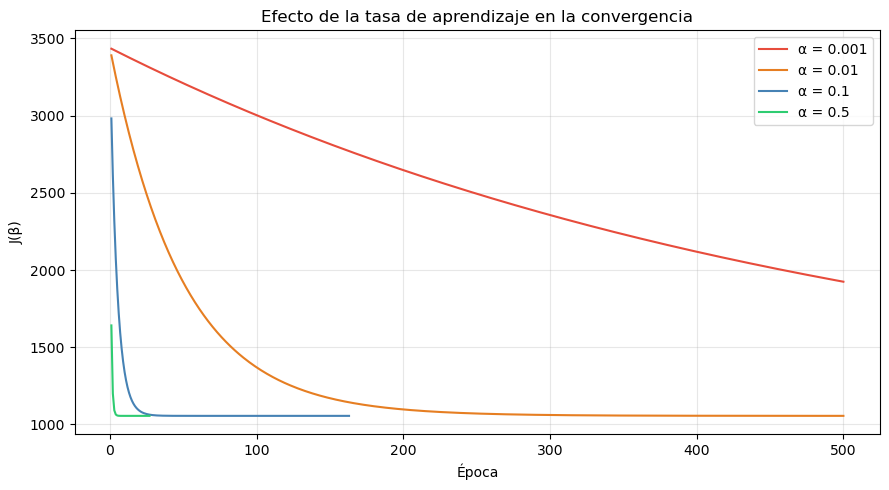

In [13]:
alphas = [0.001, 0.01, 0.1, 0.5]
colores = ["#e74c3c", "#e67e22", "steelblue", "#2ecc71"]
epocas_max = 500

fig, ax = plt.subplots(figsize=(9, 5))

for alpha, color in zip(alphas, colores):
    modelo_tmp = RegresionLineal()
    modelo_tmp.fit(X_norm, y, metodo="gradiente", alpha=alpha, epocas=epocas_max, tolerancia=1e-12)
    ax.plot(
        range(1, len(modelo_tmp.historial_loss_) + 1),
        modelo_tmp.historial_loss_,
        label=f"α = {alpha}",
        color=color
    )

ax.set_xlabel("Época")
ax.set_ylabel("J(β)")
ax.set_title("Efecto de la tasa de aprendizaje en la convergencia")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("../reports/figures/efecto_tasa_aprendizaje.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.2 ¿Cuándo falla la solución analítica?

La solución analítica requiere resolver el sistema $X^\top X\,\boldsymbol{\beta} = X^\top \mathbf{y}$, lo cual exige que $X^\top X$ sea invertible. Se demostró (sección 1.2) que esto equivale a que las columnas de $X$ sean linealmente independientes. ¿Cuándo se viola esta condición?

**Caso 1. Multicolinealidad perfecta:** si una feature es combinación lineal exacta de otras (por ejemplo, si se incluyera una columna que fuera $2 \cdot \text{longitude} + 3$), las columnas de $X$ serían linealmente dependientes, $X^\top X$ sería singular y el sistema no tendría solución única.

**Caso 2. Más features que observaciones ($n + 1 > m$):** si la matriz $X$ tiene más columnas que filas, su rango máximo es $m < n + 1$, lo que implica que las columnas son necesariamente dependientes. En este caso, las ecuaciones normales tienen infinitas soluciones.

En este proyecto, $X \in \mathbb{R}^{1187 \times 3}$ con columnas (unos, longitude, latitude). Ninguna es combinación lineal de las otras, y $m = 1187 \gg n + 1 = 3$. Se puede verificar numéricamente que $X^\top X$ es invertible comprobando que su número de condición es finito y sus valores propios son estrictamente positivos.

In [14]:
XtX = X_norm.T @ X_norm
valores_propios = np.linalg.eigvalsh(XtX)
numero_condicion = np.linalg.cond(XtX)

print("Valores propios de X^T X:")
for i, vp in enumerate(valores_propios):
    print(f"  λ_{i} = {vp:.4f}")

print(f"\nNúmero de condición: {numero_condicion:.2f}")
print(f"Todos positivos: {np.all(valores_propios > 0)}")

Valores propios de X^T X:
  λ_0 = 1101.7016
  λ_1 = 1187.0000
  λ_2 = 1272.2984

Número de condición: 1.15
Todos positivos: True


### 4.3 Interpretación geofísica de los coeficientes

Los coeficientes obtenidos no son solo números que minimizan una función de costo, sino que describen una relación geométrica real entre la posición geográfica de los sismos y la profundidad de su hipocentro.

El modelo (en espacio normalizado) es:

$$\widehat{\text{depth}} = 62.15 + 27.92 \cdot z_{\text{lon}} - 9.35 \cdot z_{\text{lat}}$$

donde $z_{\text{lon}}$ y $z_{\text{lat}}$ son las features estandarizadas. Pasemos a la interpretación de cada coeficiente:

- **$\beta_0 = 62.15$ km:** profundidad predicha cuando ambas features están en su media. Es un valor intermedio entre los sismos corticales (0–30 km) y los de subducción (100–200 km), lo cual refleja la limitación del modelo lineal al promediar dos regímenes distintos.
- **$\beta_1 = 27.92$ km por desviación estándar de longitude:** al moverse una desviación estándar hacia el este (longitude más positiva, hacia el interior del continente), la profundidad predicha aumenta ~28 km. Esto es consistente con la geometría de la **zona de Wadati-Benioff**: la placa de Nazca se subduce bajo la Sudamericana, hundiéndose progresivamente hacia el este.
- **$\beta_2 = -9.35$ km por desviación estándar de latitude:** al moverse una desviación estándar hacia el norte (latitude más positiva), la profundidad predicha disminuye ~9 km. El efecto es menor que el de la longitude, consistente con que la geometría de subducción varía poco en dirección norte-sur dentro de la zona del dataset.

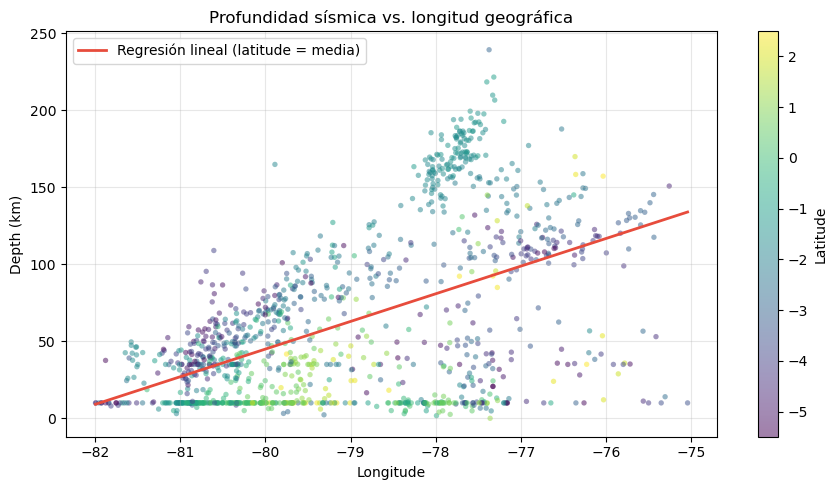

In [15]:
y_pred_analitico = modelo_analitico.predict(X_norm)

fig, ax = plt.subplots(figsize=(9, 5))

scatter = ax.scatter(
    df["longitude"], df["depth"],
    c=df["latitude"], cmap="viridis",
    alpha=0.5, s=15, edgecolors="none"
)

lon_rango = np.linspace(df["longitude"].min(), df["longitude"].max(), 100)
lon_rango_norm = (lon_rango - mu[0]) / sigma[0]
lat_media_norm = 0.0

X_recta = np.column_stack([
    np.ones(100),
    lon_rango_norm,
    np.full(100, lat_media_norm)
])
y_recta = modelo_analitico.predict(X_recta)

ax.plot(
    lon_rango, y_recta,
    color="#e74c3c", linewidth=2,
    label="Regresión lineal (latitude = media)"
)

cbar = fig.colorbar(scatter, ax=ax)
cbar.set_label("Latitude")

ax.set_xlabel("Longitude")
ax.set_ylabel("Depth (km)")
ax.set_title("Profundidad sísmica vs. longitud geográfica")
ax.legend()
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig("../reports/figures/longitude_vs_depth_regresion.png", dpi=150, bbox_inches="tight")
plt.show()

El gráfico anterior es un corte transversal del modelo: fija latitude en su media y muestra cómo varía la predicción con longitude. Pero el modelo tiene dos features, así que su superficie de predicción no es una recta sino un **plano** en el espacio (longitude, latitude, depth). Para visualizar simultáneamente el efecto de ambos coeficientes ($\beta_1$ en la dirección este-oeste y $\beta_2$ en la dirección norte-sur), se grafica este plano junto con las observaciones.

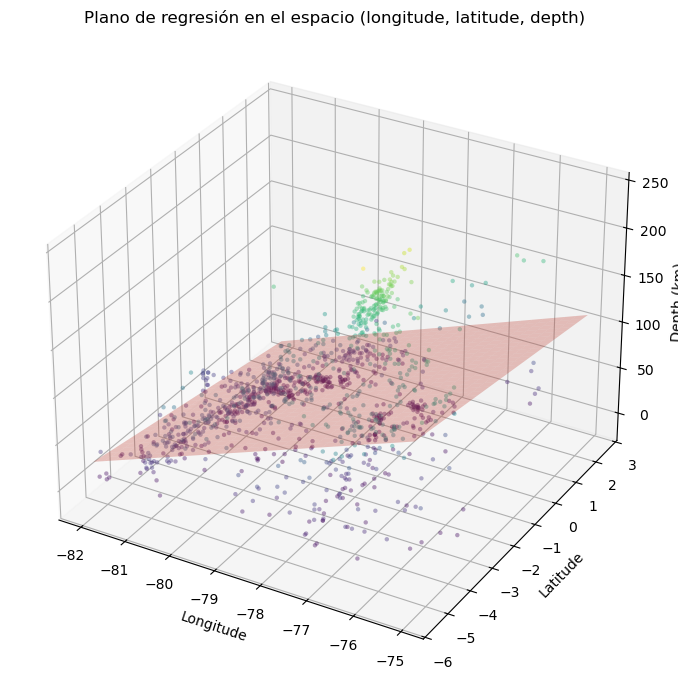

In [16]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    df["longitude"], df["latitude"], df["depth"],
    c=df["depth"], cmap="viridis",
    alpha=0.4, s=10, edgecolors="none"
)

lon_grid = np.linspace(df["longitude"].min(), df["longitude"].max(), 30)
lat_grid = np.linspace(df["latitude"].min(), df["latitude"].max(), 30)
LON, LAT = np.meshgrid(lon_grid, lat_grid)

LON_norm = (LON - mu[0]) / sigma[0]
LAT_norm = (LAT - mu[1]) / sigma[1]

DEPTH_pred = (
    modelo_analitico.coeficientes_[0]
    + modelo_analitico.coeficientes_[1] * LON_norm
    + modelo_analitico.coeficientes_[2] * LAT_norm
)

ax.plot_surface(LON, LAT, DEPTH_pred, alpha=0.3, color="#e74c3c")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_zlabel("Depth (km)")
ax.set_title("Plano de regresión en el espacio (longitude, latitude, depth)")

fig.tight_layout()
fig.savefig("../reports/figures/plano_regresion_3d.png", dpi=150, bbox_inches="tight")
plt.show()

El plano rojo se inclina en dos direcciones: hacia el este (el efecto de $\beta_1 = 27.92$, la inclinación dominante) y ligeramente hacia el sur (el efecto de $\beta_2 = -9.35$, más sutil). Ambos coeficientes son ahora visibles geométricamente como las pendientes del plano en cada eje.

La dispersión de los puntos alrededor del plano confirma lo que las métricas indicaron ($R^2 = 0.30$): el modelo captura la tendencia general de la zona de Wadati-Benioff, pero un solo plano no puede separar los dos regímenes de profundidad (sismos corticales concentrados cerca de 0 km y sismos de subducción entre 100–200 km). Este tipo de estructura bimodal requiere modelos más expresivos, un tema que se abordará en fases posteriores del portafolio.

## 5. Conclusiones y Aprendizajes

En este notebook se implementó regresión lineal múltiple desde cero, cubriendo tanto el fundamento con rigurosidad matemática como la implementación numérica.

**Lo que se construyó:**
- La derivación completa de la función de costo, su gradiente, y las dos vías de solución (ecuaciones normales y gradient descent), con demostraciones explícitas de la existencia y unicidad del mínimo (Weierstrass + coercividad + convexidad estricta).
- Una clase `RegresionLineal` en NumPy que resuelve el problema por ambos métodos, verificada contra Scikit-learn con diferencias del orden de $10^{-13}$ (solución analítica) y $10^{-4}$ (gradient descent).

**Lo que se observó:**
- El modelo lineal captura la tendencia general de la zona de Wadati-Benioff ($\beta_1 > 0$: más al este, más profundo), pero con $R^2 = 0.30$ y RMSE $\approx 46$ km, un solo plano no logra separar los dos regímenes de profundidad (corticales 0–30 km y subducción 100–200 km).
- Gradient descent convergió en 118 épocas con $\alpha = 0.1$, y el experimento con diferentes tasas de aprendizaje confirmó los tres regímenes teóricos: convergencia lenta, adecuada y rápida.
- La verificación de valores propios de $X^\top X$ ($\lambda_{\min} = 1101.70$, número de condición $= 1.15$) confirmó numéricamente la hipótesis de independencia lineal que sustenta toda la teoría.

**Limitaciones:**
- La distribución bimodal de depth viola la suposición implícita de que la relación entre features y objetivo es capturada por una única función lineal. Modelos más expresivos (regresión polinómica, árboles de decisión, o segmentación previa por régimen) podrían mejorar sustancialmente el ajuste.
- No se realizó partición en conjuntos de entrenamiento, validación y prueba, ya que el objetivo era verificar la implementación, no evaluar la capacidad de generalización.

**Decisiones técnicas clave:**
- `np.linalg.solve` en lugar de `np.linalg.inv` para estabilidad numérica.
- Normalización z-score para garantizar convergencia adecuada de gradient descent.
- Comparación de los tres métodos (analítico, GD, sklearn) sobre los mismos datos normalizados para que los coeficientes sean directamente comparables.

---

## Referencias

- **Dataset:** USGS Earthquake Hazards Program. USGS Earthquake Catalog, consultado via FDSNWS Event Web Service. https://earthquake.usgs.gov/fdsnws/event/1/
- **NumPy:** Harris, C.R. et al. (2020). Array programming with NumPy. *Nature*, 585, 357–362.
- **Scikit-learn:** Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *JMLR*, 12, 2825–2830.
- **Zona de Wadati-Benioff:** Wadati, K. (1935). On the activity of deep-focus earthquakes in the Japan Islands and neighbourhoods. *Geophysical Magazine*, 8, 305–325.